In [1]:
import os

# Numpy is a math lib
import numpy as np

# Matplotlib is a graphing lib
import matplotlib.pyplot as plt

# Math is Python's math lib
import math

import random

# Set seed for experimental reproducibility (Change if you want different outcomes)
seed = 1 
np.random.seed(seed)
random.seed(seed)

CIRCLES_OS_PATH = 'data/circles/'
RECTANGLES_OS_PATH = 'data/rectangles/'
TRIANGLES_OS_PATH = 'data/triangles/'

## Create Shapes (Data Augmentation)

## Helpers

In the below cell we define some helper functions for creating the dataset.

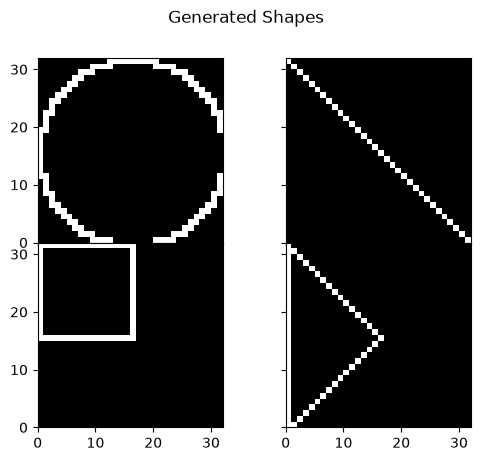

In [5]:
# Amount of datapoints in set (SAMPLES = 1000 => (1000 Circles, 1000 Rectangles, 1000 Triangles) = 3000 datapoints)
SAMPLES = 5000
WIDTH = 32 # Change as needed
HEIGHT = 32 # Changed as needed

circles = np.zeros((SAMPLES,WIDTH,HEIGHT), dtype=np.uint8)
rectangles = np.zeros((SAMPLES,WIDTH,HEIGHT), dtype=np.uint8)
triangles = np.zeros((SAMPLES,WIDTH,HEIGHT), dtype=np.uint8)

class Point:
    x = 0
    y = 0
    def __init__(self, x, y):
        self.x = x
        self.y = y

screen = np.zeros((WIDTH, HEIGHT), dtype=np.int8)
np.set_printoptions(threshold=np.inf)

def clear_screen():
    global screen
    screen = np.zeros((WIDTH, HEIGHT), dtype=np.int8)

def show_screen(axs):
    axs.imshow(screen, cmap='gray', vmin=0, vmax=1,extent=(0,WIDTH,0,HEIGHT))


def linear_interpolation(start, end, t):
    return (1-t)*start + t*end

def generate_circle(point, radius, file_name, index, save_individual, random_offset):
    current_x = math.cos(0)
    current_y = math.sin(0)
    angle = 0
    while angle <= (math.pi*2):
        new_radius = radius
        if np.random.random() > 0.15 and random_offset > 0:
            new_radius = radius + random.randrange(-random_offset, random_offset)
        index_x = round((current_x*new_radius)+point.x)
        index_y = round((current_y*new_radius)+point.y)
        if index_x < WIDTH and index_x >= 0 and index_y < HEIGHT and index_y >= 0:     
            screen[index_x][index_y] = 1
        current_x = math.cos(angle)
        current_y = math.sin(angle)
        angle += 0.001
    
    if not os.path.exists(CIRCLES_OS_PATH):
        os.mkdir(CIRCLES_OS_PATH)

    if save_individual:
        np.save(F'{CIRCLES_OS_PATH}/{file_name}', screen)
    circles[index] = screen
            

def generate_line(start_point, end_point, random_offset):
    t = 0

    while t <= 1:
        offset_y = 0
        offset_x = 0
        if random_offset > 0:
            if np.random.random() > 0.50:
                offset_y = random.randrange(-random_offset, random_offset)
            else:
                offset_x = random.randrange(-random_offset, random_offset)
        index_x = round(linear_interpolation(start_point.x, end_point.x, t))+offset_x
        index_y = round(linear_interpolation(start_point.y, end_point.y, t))+offset_y
        if index_x < WIDTH and index_x >= 0 and index_y < HEIGHT and index_y >= 0: 
            screen[index_x][index_y] = 1
        t += 0.001

def generate_rectangle(top_left, bottom_right, file_name, index, save_individual, random_offset):
    # Top Line
    generate_line(top_left, Point(bottom_right.x, top_left.y),random_offset)
    # Bottom Line
    generate_line(Point(top_left.x, bottom_right.y), bottom_right,random_offset)
    #Right Line
    generate_line(top_left, Point(top_left.x, bottom_right.y),random_offset)
    #Left Line
    generate_line(Point(bottom_right.x, top_left.y), bottom_right,random_offset)
    if not os.path.exists(RECTANGLES_OS_PATH):
        os.mkdir(RECTANGLES_OS_PATH)

    if save_individual:
        np.save(F'{RECTANGLES_OS_PATH}/{file_name}', screen)
    rectangles[index] = screen   

def generate_triangle(vertex_1, vertex_2, vertex_3, file_name, index, save_individual, random_offset):
    generate_line(vertex_1, vertex_2,random_offset)
    generate_line(vertex_2, vertex_3,random_offset)
    generate_line(vertex_3, vertex_1,random_offset)
    if not os.path.exists(TRIANGLES_OS_PATH):
        os.mkdir(TRIANGLES_OS_PATH)

    if save_individual:
        np.save(F'{TRIANGLES_OS_PATH}/{file_name}', screen) 
    triangles[index] = screen      

fig = plt.figure()
gs = fig.add_gridspec(2,2, hspace=0,wspace=0)
(axs1,axs2),(axs3,axs4) = gs.subplots(sharex=True, sharey=True)
fig.suptitle('Generated Shapes')

generate_circle(Point(WIDTH/2, HEIGHT/2),WIDTH/2,'test', 0, False, 0)
show_screen(axs1)

clear_screen()

generate_line(Point(0,0),Point(WIDTH, HEIGHT), 0)
show_screen(axs2)

clear_screen()

generate_rectangle(Point(0,0),Point(WIDTH/2, HEIGHT/2), 'test', 0, False, 0)
show_screen(axs3)

clear_screen()

generate_triangle(Point(0,0),Point(WIDTH,0),Point(WIDTH/2, HEIGHT/2), 'test', 0, False, 0)
show_screen(axs4)

# Generate Dataset

In [6]:
def generate_circle_samples():
    for i in range(SAMPLES):
        pos_x = np.random.random() * WIDTH
        pos_y = np.random.random() * HEIGHT
        r = (np.random.random() * (WIDTH/2))+1 
        generate_circle(Point(pos_x,pos_y), r, F'circle-{i}', i, True, 0)
        print(F'Finished Generating {i+1}/{SAMPLES} Circle')
        clear_screen()

def generate_rectangle_samples():
    #fig = plt.figure()
    #gs = fig.add_gridspec(2, 5, hspace=0, wspace=0)
    #axs = gs.subplots()
    for i in range(SAMPLES):
        pos1_x = (np.random.random() * WIDTH) + ((np.random.random() * WIDTH/2) - WIDTH/4)
        pos1_y = (np.random.random() * HEIGHT) + ((np.random.random() * HEIGHT/2) - HEIGHT/4)
        pos2_x = (np.random.random() * WIDTH) + ((np.random.random() * WIDTH/2) - WIDTH/4)
        pos2_y = (np.random.random() * HEIGHT) + ((np.random.random() * HEIGHT/2) - HEIGHT/4)

        if (pos1_x >= WIDTH and pos2_x >= WIDTH) or (pos1_y >= HEIGHT and pos2_y >= HEIGHT) or (pos1_x < 0 and pos2_x < 0) or (pos1_y < 0 and pos2_y < 0):
            pos1_x = (np.random.random() * WIDTH)
            pos1_y = (np.random.random() * HEIGHT)
            pos2_x = (np.random.random() * WIDTH)
            pos2_y = (np.random.random() * HEIGHT)

        generate_rectangle(Point(pos1_x, pos1_y), Point(pos2_x, pos2_y), F'rectangle-{i}', i, True, 0)
        print(F'Finished Generating {i+1}/{SAMPLES} Rectangle')
        #if i < 5:
        #    show_screen(axs[0][i])
        #else:
        #    show_screen(axs[1][i-5])
        clear_screen()


def generate_triangle_samples():
    for i in range(SAMPLES):
        pos1_x = (np.random.random() * WIDTH) + ((np.random.random() * WIDTH/2) - WIDTH/4)
        pos1_y = (np.random.random() * HEIGHT) + ((np.random.random() * HEIGHT/2) - HEIGHT/4)
        pos2_x = (np.random.random() * WIDTH) + ((np.random.random() * WIDTH/2) - WIDTH/4)
        pos2_y = (np.random.random() * HEIGHT) + ((np.random.random() * HEIGHT/2) - HEIGHT/4)
        pos3_x = (np.random.random() * WIDTH) + ((np.random.random() * WIDTH/2) - WIDTH/4)
        pos3_y = (np.random.random() * HEIGHT) + ((np.random.random() * HEIGHT/2) - HEIGHT/4)

        if (pos1_x >= WIDTH and pos2_x >= WIDTH and pos3_x >= WIDTH) or (pos1_y >= HEIGHT and pos2_y >= HEIGHT and pos3_y >= HEIGHT) or (pos1_x < 0 and pos2_x < 0 and pos3_x < 0) or (pos1_y < 0 and pos2_y < 0 and pos3_y < 0):
            pos1_x = (np.random.random() * WIDTH)
            pos1_y = (np.random.random() * HEIGHT)
            pos2_x = (np.random.random() * WIDTH)
            pos2_y = (np.random.random() * HEIGHT)

        generate_triangle(Point(pos1_x, pos1_y), Point(pos2_x, pos2_y), Point(pos3_x, pos3_y), F'triangle-{i}', i, True, 0)
        print(F'Finished Generating {i+1}/{SAMPLES} Triangle')
        clear_screen()


generate_circle_samples()

#np.savez(F'{CIRCLES_OS_PATH}/circle_comp', circles)

generate_rectangle_samples()

#np.savez(F'{RECTANGLES_OS_PATH}/rectangle_comp', rectangles)

generate_triangle_samples()

#np.savez(F'{TRIANGLES_OS_PATH}/triangle_comp', triangles)

Finished Generating 1/5000 Circle
Finished Generating 2/5000 Circle
Finished Generating 3/5000 Circle
Finished Generating 4/5000 Circle
Finished Generating 5/5000 Circle
Finished Generating 6/5000 Circle
Finished Generating 7/5000 Circle
Finished Generating 8/5000 Circle
Finished Generating 9/5000 Circle
Finished Generating 10/5000 Circle
Finished Generating 11/5000 Circle
Finished Generating 12/5000 Circle
Finished Generating 13/5000 Circle
Finished Generating 14/5000 Circle
Finished Generating 15/5000 Circle
Finished Generating 16/5000 Circle
Finished Generating 17/5000 Circle
Finished Generating 18/5000 Circle
Finished Generating 19/5000 Circle
Finished Generating 20/5000 Circle
Finished Generating 21/5000 Circle
Finished Generating 22/5000 Circle
Finished Generating 23/5000 Circle
Finished Generating 24/5000 Circle
Finished Generating 25/5000 Circle
Finished Generating 26/5000 Circle
Finished Generating 27/5000 Circle
Finished Generating 28/5000 Circle
Finished Generating 29/5000 C